# Pipeline completo (DONREP) — corrida sobre TODO el catálogo

Copia de `mvp_pipeline.ipynb` (usado para calibrar contra el golden set) para correr el pipeline sobre las 281 filas del catálogo completo. Usa carpetas de cache y output separadas (`cache_full/`, `output_full/`) para no mezclar resultados con las corridas de calibración en `cache/` / `output/`.

## Etapa 0 — Carga de datos

Librerias 

In [84]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd

INPUT_XLSX = ROOT / "input" / "products.xlsx"
COL_REF, COL_BRAND, COL_NAME = "Ref Proveedor", "Marca", "Nombre"

df = pd.read_excel(INPUT_XLSX, dtype={COL_REF: str})
df = df[[COL_REF, COL_BRAND, COL_NAME]].copy()
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()
df = df[df[COL_REF].notna() & (df[COL_REF] != "") & (df[COL_REF] != "nan")].reset_index(drop=True)

print(f"{len(df)} productos cargados")
df.head(10)

281 productos cargados


,Ref Proveedor,Marca,Nombre
0,8550504748,MOTRIO,10W30 MOTRIO 1LX12UN
1,8550504747,MOTRIO,10W30 MOTRIO 4LX4UND
2,7711737740,MOTRIO,10W30 MOTRIO 4X4 UNID
3,8550504765,MOTRIO,10W40 MOTRIO A3/B4 SS 1LX12UND
4,8550504764,MOTRIO,10W40 MOTRIO A3/B4 SS 4LX4UND
5,8550504745,MOTRIO,15W40 MOTRIO 1LX12UN
6,7711737737,MOTRIO,15W40 MOTRIO 4LX4UND
7,8550504744,MOTRIO,15W40 MOTRIO 4LX4UND
8,7711649209,RENAULT,185/65R15 ENERGY XM2
9,8550504751,MOTRIO,20W50 MOTRIO 1LX12UN


In [86]:
# Cache/output aislados de la corrida de calibracion: cache_full/ y
# output_full/ en vez de cache/ y output/. Se parchan los CACHE_DIR/LEDGER/
# IMG_DIR de cada modulo (son globals de modulo, referenciados en tiempo de
# llamada -> el parche aplica a TODAS las funciones del pipeline sin tocar
# pipeline/*.py). Correr esta celda antes que cualquier otra que use cache.
import pipeline.search as search_mod
import pipeline.prefilter as prefilter_mod
import pipeline.select as select_mod
import pipeline.fallback as fallback_mod
import pipeline.metrics as metrics_mod
import pipeline.io_excel as io_excel_mod

CACHE_ROOT = ROOT / "cache_full"
OUTPUT_ROOT = ROOT / "output_full"

search_mod.CACHE_DIR = CACHE_ROOT / "cse"
prefilter_mod.CACHE_DIR = CACHE_ROOT / "prefilter"
select_mod.CACHE_DIR = CACHE_ROOT / "select"
fallback_mod.CACHE_DIR = CACHE_ROOT / "fallback"
metrics_mod.LEDGER = CACHE_ROOT / "metrics" / "events.jsonl"
io_excel_mod.IMG_DIR = OUTPUT_ROOT / "images"

for _d in [search_mod.CACHE_DIR, prefilter_mod.CACHE_DIR, select_mod.CACHE_DIR,
           fallback_mod.CACHE_DIR, metrics_mod.LEDGER.parent, io_excel_mod.IMG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"cache -> {CACHE_ROOT}")
print(f"output -> {OUTPUT_ROOT}")

cache -> /Users/nataliavillegas/Documents/FUTURE/DONREP/image_processor_matcher/cache_full
output -> /Users/nataliavillegas/Documents/FUTURE/DONREP/image_processor_matcher/output_full


## Etapa 1 — Normalización de nombres

Es importante revisar visualmente `nombre_original` vs `nombre_limpio` / `termino_busqueda` luego de la normalizacion. De ser necesario se puede ajustar `config/abbreviations.py` .

In [87]:
from pipeline.normalize import normalize_df

df_norm = normalize_df(df, col_nombre=COL_NAME, col_marca=COL_BRAND)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 300)
df_norm[["nombre_original", "nombre_limpio", "termino_busqueda"]].head(10)

,nombre_original,nombre_limpio,termino_busqueda
0,10W30 MOTRIO 1LX12UN,10W30 MOTRIO 1L,10W30 MOTRIO 1L
1,10W30 MOTRIO 4LX4UND,10W30 MOTRIO 4L,10W30 MOTRIO 4L
2,10W30 MOTRIO 4X4 UNID,10W30 MOTRIO 4X4 UND,10W30 MOTRIO 4X4 UND
3,10W40 MOTRIO A3/B4 SS 1LX12UND,10W40 MOTRIO A3/B4 SS 1L,10W40 MOTRIO A3/B4 SS 1L
4,10W40 MOTRIO A3/B4 SS 4LX4UND,10W40 MOTRIO A3/B4 SS 4L,10W40 MOTRIO A3/B4 SS 4L
5,15W40 MOTRIO 1LX12UN,15W40 MOTRIO 1L,15W40 MOTRIO 1L
6,15W40 MOTRIO 4LX4UND,15W40 MOTRIO 4L,15W40 MOTRIO 4L
7,15W40 MOTRIO 4LX4UND,15W40 MOTRIO 4L,15W40 MOTRIO 4L
8,185/65R15 ENERGY XM2,185/65R15 ENERGY XM2,185/65R15 ENERGY XM2 RENAULT
9,20W50 MOTRIO 1LX12UN,20W50 MOTRIO 1L,20W50 MOTRIO 1L


In [88]:
# columnas estructuradas extraídas
df_norm[["nombre_original", "pack", "litraje", "pack_ambiguo", "viscosidad", "medida_llanta", "vehiculo_code_raw"]].head(10)

,nombre_original,pack,litraje,pack_ambiguo,viscosidad,medida_llanta,vehiculo_code_raw
0,10W30 MOTRIO 1LX12UN,1LX12UN,1L,False,10W30,,
1,10W30 MOTRIO 4LX4UND,4LX4UND,4L,False,10W30,,
2,10W30 MOTRIO 4X4 UNID,4X4 UND,,True,10W30,,UND
3,10W40 MOTRIO A3/B4 SS 1LX12UND,1LX12UND,1L,False,10W40,,
4,10W40 MOTRIO A3/B4 SS 4LX4UND,4LX4UND,4L,False,10W40,,
5,15W40 MOTRIO 1LX12UN,1LX12UN,1L,False,15W40,,
6,15W40 MOTRIO 4LX4UND,4LX4UND,4L,False,15W40,,
7,15W40 MOTRIO 4LX4UND,4LX4UND,4L,False,15W40,,
8,185/65R15 ENERGY XM2,,,False,,185/65R15,XM2
9,20W50 MOTRIO 1LX12UN,1LX12UN,1L,False,20W50,,


In [89]:
df_norm[["nombre_original", "pack", "litraje", "pack_ambiguo", "viscosidad", "medida_llanta", "vehiculo_code_raw"]].tail(10)

,nombre_original,pack,litraje,pack_ambiguo,viscosidad,medida_llanta,vehiculo_code_raw
271,VIDRIO LUNETA TR SA3,,,False,,,SA3
272,VIDRIO MOVIL PUERTA NDU,,,False,,,NDU
273,VIDRIO MOVIL PUERTA TRASERA DERECHA X52,,,False,,,X52
274,VIDRIO MOVIL PUERTA TRASERA IZQUIER GKO,,,False,,,GKO
275,VIDRIO PARABRISA NDU,,,False,,,NDU
276,VIDRIO PARABRISAS NKG,,,False,,,NKG
277,VIDRIO PARABRISAS OR2,,,False,,,OR2
278,VIDRIO PARABRISAS SIN SENSOR LLUVIA NDU,,,False,,,NDU
279,VIDRIO PTA TR IZ SA3,,,False,,,SA3
280,VIDRIO PUERTA DELANTERA DERECHA NDUH,,,False,,,NDUH


### Filas de pack ambiguo (revisar a mano)

Tienen expresión de pack pero sin "L" explícito, así que no se pudo separar litraje de multiplicador de caja - quedaron intactas en `nombre_limpio`. ¿`4X4 UNID` es un típo de `4LX4UND`? ¿Qué significan `3X5` / `6X1` de Castrol?

In [90]:
df_norm[df_norm["pack_ambiguo"]][["nombre_original", "nombre_limpio", "pack"]]

,nombre_original,nombre_limpio,pack
2,10W30 MOTRIO 4X4 UNID,10W30 MOTRIO 4X4 UND,4X4 UND
24,AMOR TRA MOT 4X4 DU,AMORTIGUADOR TRASERO MOTOR 4X4 DU,4X4
65,CASTROL 10W40 3X5,CASTROL 10W40 3X5,3X5
66,CASTROL 10W40 6X1,CASTROL 10W40 6X1,6X1
67,CASTROL 10W40 6X1,CASTROL 10W40 6X1,6X1
68,CASTROL 15W40 3X5,CASTROL 15W40 3X5,3X5
69,CASTROL 15W40 3X5,CASTROL 15W40 3X5,3X5
70,CASTROL 15W40 6X1,CASTROL 15W40 6X1,6X1
71,CASTROL 15W40 6X1,CASTROL 15W40 6X1,6X1
72,CASTROL 20W50 3X5,CASTROL 20W50 3X5,3X5


## Etapa 2 — Categorización de productos, con base en los nombres


In [91]:
from pipeline.categorize import categorize_df, coverage_report
coverage_report(df_norm)          # prints per-category counts + the `otros` backlog list
cd = categorize_df(df_norm)       # adds categoria / cse_profile / presentacion columns
cd[["nombre_limpio", "categoria", "cse_profile"]].head(10)

Cobertura: 281 filas, 15 categorias

   57  carroceria
   38  vidrios_espejos
   33  iluminacion
   29  lubricantes
   21  suspension_direccion
   20  merchandising
   17  frenos
   13  motor_transmision
   13  emblemas
   10  filtros
    9  refrigeracion
    7  llantas_rines
    7  baterias
    4  otros
    3  accesorios

'otros' (backlog para nuevas reglas): 4 (1%)
    - KIT JUNTA DECANTADOR NT2
    - KIT JUNTAS INDICADOR CARBURANTE
    - MODULO VARIA CLIM NM
    - PLASTIGLO 250ML TT


,nombre_limpio,categoria,cse_profile
0,10W30 MOTRIO 1L,lubricantes,baseline
1,10W30 MOTRIO 4L,lubricantes,baseline
2,10W30 MOTRIO 4X4 UND,lubricantes,baseline
3,10W40 MOTRIO A3/B4 SS 1L,lubricantes,baseline
4,10W40 MOTRIO A3/B4 SS 4L,lubricantes,baseline
5,15W40 MOTRIO 1L,lubricantes,baseline
6,15W40 MOTRIO 4L,lubricantes,baseline
7,15W40 MOTRIO 4L,lubricantes,baseline
8,185/65R15 ENERGY XM2,llantas_rines,baseline
9,20W50 MOTRIO 1L,lubricantes,baseline


## Etapa 3 — Búsqueda CSE

Una llamada por producto. **Rung 1 (`"{ref}" "{marca}"`, ambas comilladas)** es el default: la query mínima y probada. La respuesta cruda del CSE se cachea en `cache/cse/{ref}/rung1.json`, así que iterar el resto del pipeline **no vuelve a pagar** búsquedas.

Perfil por categoría → params de imagen: `baseline` = `imgType=photo,imgSize=large`; `white_dominant` añade `imgDominantColor=white`; `exact_brand` añade `exactTerms={marca}`. Sesgo de mercado `gl=co&hl=es`.

Los rungs 2–5 (sin comillas / `nombre_limpio` / etc.) existen en `pipeline/search.py` pero **no** se auto-escalan todavía

In [92]:
# Corrida completa: TODO el catalogo, no el golden set de 1-2 por
# categoria. La variable se sigue llamando `golden` para no tener que tocar
# el resto de las celdas del notebook, pero aqui contiene las 281 filas.
golden = cd.reset_index(drop=True)

print(f"Set completo: {len(golden)} productos, {golden['categoria'].nunique()} categorias")
golden[["Ref Proveedor", "Marca", "nombre_limpio", "categoria", "cse_profile"]]

Set completo: 281 productos, 15 categorias


,Ref Proveedor,Marca,nombre_limpio,categoria,cse_profile
0,8550504748,MOTRIO,10W30 MOTRIO 1L,lubricantes,baseline
1,8550504747,MOTRIO,10W30 MOTRIO 4L,lubricantes,baseline
2,7711737740,MOTRIO,10W30 MOTRIO 4X4 UND,lubricantes,baseline
3,8550504765,MOTRIO,10W40 MOTRIO A3/B4 SS 1L,lubricantes,baseline
4,8550504764,MOTRIO,10W40 MOTRIO A3/B4 SS 4L,lubricantes,baseline
5,8550504745,MOTRIO,15W40 MOTRIO 1L,lubricantes,baseline
6,7711737737,MOTRIO,15W40 MOTRIO 4L,lubricantes,baseline
7,8550504744,MOTRIO,15W40 MOTRIO 4L,lubricantes,baseline
8,7711649209,RENAULT,185/65R15 ENERGY XM2,llantas_rines,baseline
9,8550504751,MOTRIO,20W50 MOTRIO 1L,lubricantes,baseline


In [93]:
# rung = cual query construir:  1 -> "ref" "marca" (default) | 2 -> ref marca | 3 -> nombre_limpio
# max_queries = tope de llamadas NUEVAS a la API. OJO: el CSE gratis da
# solo 100 queries NUEVAS por dia (una sola key en .env) -> con 281
# productos esta celda NO se completa en un solo dia. Se puede re-correr
# en dias sucesivos: lo ya buscado queda en cache_full/cse/{ref}/... y no
# se vuelve a pagar, solo se piden las que faltan hasta agotar el limite
# diario de nuevo.
from pipeline.search import search_df

resultados = search_df(golden, rung=1, max_queries=len(golden))

# Resumen: cuantos candidatos trajo cada producto y de que dominios
resumen = pd.DataFrame([
    {"ref": ref,
     "n_candidatos": len(cands),
     "dominios": ", ".join(sorted({c["displayLink"] for c in cands})[:5])}
    for ref, cands in resultados.items()
])
resumen

  260604573R: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  260602042R: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  8200701356: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  260608405R: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  260609542R: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  260602509R: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  8660006943: busqueda fallida, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?):

,ref,n_candidatos,dominios
0,8550504748,7,"motrio.com.co, www.imotriz.com"
1,8550504747,6,"motrio.com.co, www.imotriz.com"
2,7711737740,10,"es.scribd.com, motrio.com.co, www.homecenter.com.co, www..."
3,8550504765,10,"listado.tucarro.com.co, motrio.com.co, www.imotriz.com, ..."
4,8550504764,10,"listado.tucarro.com.co, motrio.com.co, www.imotriz.com, ..."
5,8550504745,10,"listado.mercadolibre.com.co, listado.tucarro.com.co, mot..."
6,7711737737,10,"es.scribd.com, motrio.com.co, www.imotriz.com, www.merca..."
7,8550504744,10,"listado.tucarro.com.co, motrio.com.co, www.importadorasa..."
8,7711649209,10,"listado.mercadolibre.com.co, listado.tucarro.com.co"
9,8550504751,10,"listado.tucarro.com.co, motrio.com.co, www.imotriz.com, ..."


In [94]:
import matplotlib.pyplot as plt

# --- Productos sin ningún candidato ---
sin_candidatos = resumen[resumen["n_candidatos"] == 0]
pct_sin = 100 * len(sin_candidatos) / len(resumen)
print(f"Productos sin candidatos: {len(sin_candidatos)} de {len(resumen)} ({pct_sin:.1f}%)")
sin_candidatos

# --- Distribución de cuántos candidatos trajo cada producto ---
distribucion = (
    resumen["n_candidatos"]
    .value_counts()
    .sort_index()
    .rename_axis("n_candidatos")
    .reset_index(name="n_productos")
)
distribucion


Productos sin candidatos: 3 de 120 (2.5%)


,n_candidatos,n_productos
0,0,3
1,1,3
2,2,1
3,3,1
4,5,1
5,6,2
6,7,1
7,8,1
8,9,1
9,10,106


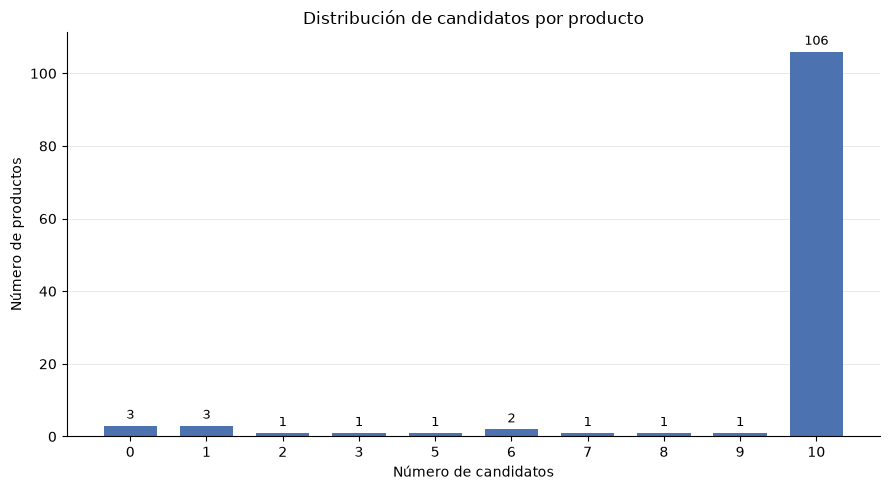

In [95]:
# --- Gráfico de barras de la distribución ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    distribucion["n_candidatos"].astype(str),
    distribucion["n_productos"],
    color="#4C72B0",
    width=0.7,
)

ax.set_xlabel("Número de candidatos")
ax.set_ylabel("Número de productos")
ax.set_title("Distribución de candidatos por producto")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="lightgray", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

# etiquetas encima de cada barra
for x, y in zip(distribucion["n_candidatos"].astype(str), distribucion["n_productos"]):
    ax.text(x, y + max(distribucion["n_productos"]) * 0.01, str(y), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [96]:
# Preview inline: miniaturas por producto para revisar a ojo el pool crudo
from IPython.display import HTML, display

for ref, cands in resultados.items():
    fila = golden[golden["Ref Proveedor"] == ref].iloc[0]
    print(f"{ref}  |  {fila['nombre_limpio']}  |  {fila['categoria']} "
        f"({fila['cse_profile']})  |  {len(cands)} candidatos")
    imgs = "".join(
        f'<img src="{c["thumbnailLink"]}" title="{c["displayLink"]}" '
        f'style="height:90px;margin:2px;border:1px solid #ccc">'
        for c in cands if c["thumbnailLink"]
    )
    display(HTML(imgs or "<i>(sin candidatos)</i>"))


8550504748  |  10W30 MOTRIO 1L  |  lubricantes (baseline)  |  7 candidatos


8550504747  |  10W30 MOTRIO 4L  |  lubricantes (baseline)  |  6 candidatos


7711737740  |  10W30 MOTRIO 4X4 UND  |  lubricantes (baseline)  |  10 candidatos


8550504765  |  10W40 MOTRIO A3/B4 SS 1L  |  lubricantes (baseline)  |  10 candidatos


8550504764  |  10W40 MOTRIO A3/B4 SS 4L  |  lubricantes (baseline)  |  10 candidatos


...

7717274352  |  GORRA R5 VERDE  |  merchandising (exact_brand)  |  10 candidatos


7717079986  |  GORRA RENAULT VERDE LOGO NARANJA  |  merchandising (exact_brand)  |  10 candidatos


8201037748  |  INYECTOR SAS-NS  |  motor_transmision (baseline)  |  10 candidatos


8660005312  |  KIT EMBRAGUE MOTOR MG1 SCS  |  motor_transmision (baseline)  |  10 candidatos


801010094R  |  PUERTA DELANTERA IZQUIERDA DU  |  carroceria (baseline)  |  10 candidatos


## Etapa 4 — Pre-filtro (sin Gemini)

Sobre el pool crudo de la Etapa 3: dedupe por URL y por contenido visual (perceptual hash —> misma foto servida desde dos dominios distintos), descarta resolución baja / aspect ratio de banner / dominios en `config/domains.py`, y luego **ordena** (no descarta) por dominio prioritario + score de fondo blanco calculado del thumbnail. Los primeros `keep=6` que sobreviven se verifican con un HEAD (sin bajar la imagen completa —> Gemini la pedirá después, en memoria).

Todo el proceso escribe **solo un JSON de resultado por producto** en `cache/prefilter/{ref}.json` — no se guardan imágenes a disco, así que re-correr esta celda no vuelve a pegarle a la red.

In [97]:
# Corre el pre-filtro sobre el pool de la Etapa 3 (golden set). use_cache=True
# por defecto en prefilter_product: re-correr esta celda no re-hace los HEAD
# ni vuelve a bajar thumbnails, sirve el JSON de cache/prefilter/{ref}.json.
from pipeline.prefilter import prefilter_product

filtrados = {ref: prefilter_product(ref, cands) for ref, cands in resultados.items()}

resumen_prefiltro = pd.DataFrame([
    {"ref": ref,
     "n_input": r["n_input"],
     "n_kept": len(r["kept"]),
     "n_dropped": len(r["dropped"])}
    for ref, r in filtrados.items()
])
resumen_prefiltro


,ref,n_input,n_kept,n_dropped
0,8550504748,7,2,5
1,8550504747,6,2,4
2,7711737740,10,3,7
3,8550504765,10,3,7
4,8550504764,10,4,6
5,8550504745,10,3,7
6,7711737737,10,1,9
7,8550504744,10,3,7
8,7711649209,10,0,10
9,8550504751,10,4,6


In [98]:
# Preview inline: candidatos sobrevivientes (con su bg_score) y por que se
# cayeron los demas -> clave para calibrar MIN_SIDE / MAX_ASPECT_RATIO /
# HASH_MAX_DISTANCE y para ir llenando config/domains.py con evidencia real.
for ref, r in filtrados.items():
    fila = golden[golden["Ref Proveedor"] == ref].iloc[0]
    print(f"{ref}  |  {fila['nombre_limpio']}  |  {fila['categoria']}  "
        f"|  {len(r['kept'])}/{r['n_input']} sobrevivieron")

    imgs = "".join(
        f'<div style="display:inline-block;text-align:center;margin:2px">'
        f'<img src="{c["thumbnailLink"]}" title="{c["displayLink"]}" '
        f'style="height:90px;border:1px solid #ccc"><br>'
        f'<small>{c["bg_score"]}</small></div>'
        for c in r["kept"] if c["thumbnailLink"]
    )
    display(HTML(imgs or "<i>(sin candidatos sobrevivientes)</i>"))

    if r["dropped"]:
        razones = pd.Series([reason for _, reason in r["dropped"]]).value_counts()
        print("  descartados:", dict(razones))


8550504748  |  10W30 MOTRIO 1L  |  lubricantes  |  2/7 sobrevivieron


  descartados: {'resolucion_baja 300x205': np.int64(5)}
8550504747  |  10W30 MOTRIO 4L  |  lubricantes  |  2/6 sobrevivieron


  descartados: {'resolucion_baja 300x205': np.int64(4)}
7711737740  |  10W30 MOTRIO 4X4 UND  |  lubricantes  |  3/10 sobrevivieron


  descartados: {'resolucion_baja 253x130': np.int64(2), 'resolucion_baja 149x198': np.int64(2), 'resolucion_baja 298x396': np.int64(1), 'resolucion_baja 237x315': np.int64(1), 'duplicado_visual': np.int64(1)}
8550504765  |  10W40 MOTRIO A3/B4 SS 1L  |  lubricantes  |  3/10 sobrevivieron


  descartados: {'resolucion_baja 320x320': np.int64(4), 'resolucion_baja 300x205': np.int64(3)}
8550504764  |  10W40 MOTRIO A3/B4 SS 4L  |  lubricantes  |  4/10 sobrevivieron


...

  descartados: {'duplicado_visual': np.int64(2), 'resolucion_baja 250x250': np.int64(1)}
7717079986  |  GORRA RENAULT VERDE LOGO NARANJA  |  merchandising  |  6/10 sobrevivieron


8201037748  |  INYECTOR SAS-NS  |  motor_transmision  |  5/10 sobrevivieron


  descartados: {'duplicado_visual': np.int64(2), 'resolucion_baja 428x338': np.int64(1)}
8660005312  |  KIT EMBRAGUE MOTOR MG1 SCS  |  motor_transmision  |  6/10 sobrevivieron


  descartados: {'resolucion_baja 250x187': np.int64(1), 'duplicado_visual': np.int64(1)}
801010094R  |  PUERTA DELANTERA IZQUIERDA DU  |  carroceria  |  6/10 sobrevivieron


  descartados: {'resolucion_baja 500x390': np.int64(1), 'duplicado_visual': np.int64(1)}


## Etapa 5 — Selección con Gemini (Vertex AI)

Una llamada por producto: las candidatas que sobrevivieron el pre-filtro (columna `kept` de la Etapa 4), numeradas, más un prompt que pide JSON estructurado (`response_mime_type="application/json"` + `response_schema`, mismos campos que el plan: `evaluaciones`, `seleccion`, `ranking`, `confianza`, `comentario`). Gemini evalúa criterios eliminatorios (producto correcto, marca) y de calidad (resolución, fondo, estado, empaque, limpieza), y ELIGE la mejor (se plantea un código a utilizar sobre elección en los casos borde).

Modelo por defecto: `gemini-2.5-flash` (barato, discriminación no generación). `MODEL_PRO` está declarado en `pipeline/select.py` para el ruteo a dos niveles (confianza baja → Pro) pero ese ruteo automático **no** está implementado todavía —> se pasa `model=` explícito si se quiere probar.

Reglas post-Gemini ya aplicadas dentro de `select_product`:
- `seleccion` fuera de rango → se resuelve al siguiente número del propio `ranking`, sin nueva llamada.
- marca de la imagen elegida = `no_verificable` → flag `revisar_marca`.
- `seleccion=null` o `confianza=baja` → flag `necesita_fallback` (la Etapa 5b la re-dispara automáticamente por los rungs 2–3).

Cache en `cache/select/{ref}.json` —> re-correr esta celda no vuelve a pagar la llamada a Gemini. Requiere `credentials.json` + `GOOGLE_CLOUD_PROJECT`/`GOOGLE_CLOUD_LOCATION` en `.env` (ya configurados).

In [101]:
# max_calls = tope de llamadas NUEVAS a Gemini. Vertex AI no tiene el
# limite gratis diario del CSE, pero SI se cobra por llamada -> correr esto
# sobre el catalogo completo paga precio de lista por cada producto nuevo
# (~281 la primera vez). Bajar max_calls si se quiere probar en tandas.
from pipeline.select import select_df, MODEL_FLASH

seleccionados = select_df(golden, filtrados, model=MODEL_FLASH, max_calls=len(golden))

resumen_seleccion = pd.DataFrame([
    {"ref": ref,
    "confianza": r["confianza"],
    "flags": ", ".join(r["flags"]) or "-",
    "comentario": r["comentario"]}
    for ref, r in seleccionados.items()
])
resumen_seleccion

  8660005993: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  543022720R: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  543024047R: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  543027255R: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  562103901R: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  8660006012: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)


/Users/nataliavillegas/Documents/FUTURE/DONREP/image_processor_matcher/venv/lib/python3.11/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  D40604JA0A: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  244103090R: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  7711744709: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  7711744710: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  7711575175: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  7711947963: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 intentos: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'm)
  7711375379: seleccion fallida, se reintenta en la proxima corrida (Gemini fallo tras 4 inten

,ref,confianza,flags,comentario
0,8550504748,alta,-,La imagen 1 muestra correctamente el producto '10W30 MOT...
1,8550504747,alta,-,La imagen 1 fue descartada por no mostrar el producto co...
2,7711737740,alta,-,Ambas imágenes 1 y 3 muestran el lubricante 10W30 MOTRIO...
3,8550504765,alta,-,Both images 1 and 2 correctly show the MOTRIO 10W40 0.94...
4,8550504764,alta,"sin_imagen, necesita_fallback",Ninguna de las imágenes cumple con los criterios elimina...
5,8550504745,alta,-,La imagen 2 fue descartada por no mostrar el producto ni...
6,7711737737,alta,"sin_imagen, necesita_fallback",Ninguna imagen cumple con los criterios eliminatorios. L...
7,8550504744,alta,-,La imagen 3 fue descartada porque detalles críticos del ...
8,7711649209,baja,"sin_imagen, necesita_fallback",pool vacio tras el pre-filtro
9,8550504751,alta,-,La imagen 2 fue descartada por no mostrar el producto ni...


In [ ]:
# Preview inline: candidato elegido (borde verde) + el resto del pool con la
# razon de Gemini si lo descarto. Flags a revisar a mano:
#   revisar_marca      -> la marca de la elegida no se pudo verificar
#   necesita_fallback  -> seleccion=null o confianza baja (siguiente escalon
#                          de busqueda de la Etapa 3, todavia manual)
# Se salta lo que ni siquiera se ha buscado en la Etapa 3 (ref no esta en
# `resultados`): eso no es un pool vacio real, es que search_df/escalate_df
# todavia no le tocaba (limite diario del CSE) -> no aporta nada revisarlo
# a mano todavia, solo ruido.
n_no_buscado = 0
for ref, r in seleccionados.items():
    if ref not in resultados:
        n_no_buscado += 1
        continue

    fila = golden[golden["Ref Proveedor"] == ref].iloc[0]
    sel = r["seleccion"]
    kept = filtrados.get(ref, {}).get("kept", [])
    evals = {e["imagen"]: e for e in r["evaluaciones"]}

    print(f"{ref}  |  {fila['nombre_limpio']}  |  {fila['categoria']}  "
        f"|  confianza={r['confianza']}  |  flags={', '.join(r['flags']) or '-'}")
    print(f"  {r['comentario']}")

    imgs = ""
    for i, c in enumerate(kept, start=1):
        is_sel = sel is not None and c.get("link") == sel.get("link")
        e = evals.get(i, {})
        label = "ELEGIDA" if is_sel else (e.get("razon", "") if e.get("descartada") else "")
        imgs += (
            f'<div style="display:inline-block;text-align:center;margin:3px;max-width:110px">'
            f'<img src="{c["thumbnailLink"]}" title="{c["displayLink"]}" '
            f'style="height:90px;border:{"3px solid #2a2" if is_sel else "1px solid #ccc"}"><br>'
            f'<small>{label}</small></div>'
        )
    display(HTML(imgs or "<i>(sin candidatos evaluados)</i>"))

if n_no_buscado:
    print(f"\n({n_no_buscado} productos omitidos: aun no buscados en Etapa 3, "
        f"pendientes del limite diario del CSE)")


8550504748  |  10W30 MOTRIO 1L  |  lubricantes  |  confianza=alta  |  flags=-
  La imagen 1 es la única que cumple con el producto (10W30, 0.946L equivalente a 1L) y la marca MOTRIO requeridos. Las otras imágenes fueron descartadas por no coincidir con la viscosidad o el volumen especificado, o por mostrar una marca y producto completamente diferentes.


8550504747  |  10W30 MOTRIO 4L  |  lubricantes  |  confianza=alta  |  flags=-
  Imagen 1 descartada por ser ATF MD-3 y 0.946L, en lugar de aceite de motor 10W30 y 4L. Imagen 2 descartada por no mostrar el producto requerido y tener una marca diferente ('imotriz'). La Imagen 3 muestra aceite de motor 10W-30 de la marca MOTRIO en un envase de 3.785L (1 galón), lo cual se considera un equivalente aceptable para 4L según la regla de litraje, ya que no es un tamaño claramente diferente. Por lo tanto, la Imagen 3 es la única que cumple los criterios.


7711737740  |  10W30 MOTRIO 4X4 UND  |  lubricantes  |  confianza=alta  |  flags=sin_imagen, necesita_fallback
  Ninguna de las imágenes cumple con los criterios eliminatorios. Las imágenes 1 y 3 no muestran la especificación '4X4' en el producto y el tamaño de un galón es inconsistente si 'UND' se refiere a una unidad de 1L. La imagen 2 no muestra el producto ni la marca correctos.


8550504765  |  10W40 MOTRIO A3/B4 SS 1L  |  lubricantes  |  confianza=alta  |  flags=-
  Las imágenes 1 y 5 cumplen todos los criterios. Se selecciona la imagen 1 por mostrar el frontal del producto, lo cual es preferible para catálogos.


8550504764  |  10W40 MOTRIO A3/B4 SS 4L  |  lubricantes  |  confianza=alta  |  flags=sin_imagen, necesita_fallback
  All candidate images were discarded because they failed the eliminatory criteria. Images 1, 3, 4, and 6 show a 1-gallon (3.785L) container, which is considered 'clearly another size' than the requested 4L according to the presentation rule. Image 2 shows '4GL' (likely 4 gallons) and an incorrect 15W-40 viscosity, which does not match the requested 4L and 10W40. Image 5 does not show the product at all. Therefore, no image could be selected.


...

7717079986  |  GORRA RENAULT VERDE LOGO NARANJA  |  merchandising  |  confianza=alta  |  flags=-
  Solo la imagen 4 muestra el producto correcto (gorra Renault). Las demás imágenes muestran coches en miniatura, camisetas o cajas, que no corresponden a la descripción del producto.


8201037748  |  INYECTOR SAS-NS  |  motor_transmision  |  confianza=alta  |  flags=-
  All images correctly show an inyector and pass eliminatory criteria. Image 2 is selected as it clearly verifies the RENAULT brand on its packaging and has an excellent quality score. Image 1 also has an excellent quality score but does not verify the brand. Images 3, 4, and 5 have slightly lower quality scores and do not verify the brand.


8660005312  |  KIT EMBRAGUE MOTOR MG1 SCS  |  motor_transmision  |  confianza=alta  |  flags=-
  La imagen 4 es la mejor candidata con una puntuación de calidad perfecta y la marca 'Valeo' claramente visible y consistente con el producto. Las imágenes 5 y 6 fueron descartadas por no cumplir con los criterios eliminatorios (limpieza y producto incorrecto, respectivamente).


801010094R  |  PUERTA DELANTERA IZQUIERDA DU  |  carroceria  |  confianza=alta  |  flags=revisar_marca
  Images 4 and 6 were discarded due to failing eliminatory criteria (incorrect product presentation for 4, incorrect brand for 6). Images 1 and 3 had cluttered backgrounds due to packaging. Images 2 and 5 are of excellent quality with clean white backgrounds and no packaging, making them the best choices, with image 2 selected as the primary best.



(154 productos omitidos: aun no buscados en Etapa 3, pendientes del limite diario del CSE)


## Etapa 5b — Fallback (rungs 2–3)

Re-ataca SOLO los productos que salieron de la Etapa 5 con `sin_imagen` / `necesita_fallback`: baja por la escalera de búsqueda (`rung 2` = ref+marca sin comillas, `rung 3` = `nombre_limpio`), fusiona los candidatos nuevos con el pool que ya había (dedupe por link), **excluye** las imágenes que un Gemini anterior condenó por criterio eliminatorio (producto incorrecto / marca incorrecta —> no se re-pagan ni ocupan los 6 cupos del pre-filtro; las descartadas solo por calidad o con marca `no_verificable` sí se quedan, pueden ganar contra un pool más débil), re-corre pre-filtro + selección Gemini, y se detiene en el primer rung que resuelva. `max_queries` / `max_calls` protegen los presupuestos igual que en las Etapas 3 y 5.

El resultado escalado queda en `cache/fallback/{ref}.json` —> re-correr esta celda no vuelve a pagar. `escalate_df` MUTA `resultados` / `filtrados` / `seleccionados` en su lugar, así que las celdas de la Etapa 6 exportan el pipeline ya rescatado sin cambios. El log retornado (una fila por ref+rung intentado) es la métrica de cuánto rescató cada escalón extra.

In [ ]:
# Escalado automatico para los productos flagged tras la Etapa 5. El log
# muestra que rung rescato que producto (o donde sigue perdido). Solo
# ataca los que quedaron sin_imagen/necesita_fallback, asi que un tope
# igual al tamano del catalogo no sobre-gasta.
from pipeline.fallback import escalate_df

log_fallback = escalate_df(golden, resultados, filtrados, seleccionados,
                           max_queries=len(golden), max_calls=len(golden))
log_fallback

fallback: 178 productos a escalar (rungs [2, 3])
  7711737740: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  8550504764: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  7711737746: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  7711943694: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  631007602R: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  543039724R: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cuota diaria agotada?): {
  "error": {
    "code": 429,
    "message": )
  561117076R: rung 2 fallo, se reintenta en la proxima corrida (CSE 429 (cu

,ref,rung,resultado,flags
0,7711737740,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
1,8550504764,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
2,7711737746,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
3,7711943694,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
4,631007602R,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
5,543039724R,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
6,561117076R,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
7,8660006012,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
8,7711744709,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."
9,7711744710,2,error_red,"CSE 429 (cuota diaria agotada?): {\n ""error"": {\n ""c..."


## Métricas — cobertura y costo

Dos vistas sobre el mismo run:

- **Cobertura** (`selection_report`): embudo por producto (candidatos CSE → sobreviven pre-filtro → evaluadas por Gemini → seleccionada) + tasa de éxito, confianza y flags. La línea "sin imagen por etapa" dice DÓNDE se pierde cada producto —> si el pool CSE está vacío, el fix es la búsqueda (rungs/perfiles); si Gemini descarta todo, el fix es el prompt o el pre-filtro.
- **Costo** (`cost_report` / `retry_report`): leídos del ledger `cache/metrics/events.jsonl`, donde cada llamada NUEVA (no cacheada) a CSE/Gemini y cada reintento escriben una línea. Los cache-hits no cuestan y no se registran. Los tokens de Gemini vienen de `usage_metadata` (el thinking se factura como salida) y quedan también dentro de `cache/select/{ref}.json` (`usage`, `modelo`, `intentos`).

Nota: los `cache/select/{ref}.json` creados ANTES de esta instrumentación no traen tokens; para backfillear, borrar `cache/select/` y re-correr la Etapa 5 (se re-paga la llamada).

In [ ]:
# Embudo de cobertura por producto + resumen agregado (tasa de exito,
# confianza, flags, y en que etapa se pierden los productos sin imagen).
from pipeline.metrics import selection_report

por_ref, resumen = selection_report(golden, resultados, filtrados, seleccionados)
por_ref

104/281 productos con imagen (37%)
  confianza: {'baja': 163, 'alta': 114, 'media': 4}
  flags: {'necesita_fallback': 178, 'sin_imagen': 177, 'revisar_marca': 42, 'descarga_thumbnail': 1}
  sin imagen por etapa: CSE vacio=159, prefiltro vacio=6, Gemini descarto todo=16


,ref,n_cse,n_prefiltro,n_evaluadas,seleccionada,confianza,flags
0,8550504748,7,2,4,True,alta,-
1,8550504747,6,2,3,True,alta,-
2,7711737740,10,3,3,False,alta,"sin_imagen, necesita_fallback"
3,8550504765,10,3,6,True,alta,-
4,8550504764,10,4,6,False,alta,"sin_imagen, necesita_fallback"
5,8550504745,10,3,6,True,alta,-
6,7711737737,10,1,3,True,alta,-
7,8550504744,10,3,5,True,alta,-
8,7711649209,10,0,6,True,alta,-
9,8550504751,10,4,5,True,alta,-


In [ ]:
# Gasto real acumulado del ledger (queries CSE facturables por dia + tokens
# Gemini a precios de lista) y reintentos por error transitorio.
from pipeline.metrics import cost_report, retry_report

display(cost_report())
retry_report()

Costo total estimado: $1.1035 USD (120 queries CSE, 115 llamadas Gemini)


,servicio,llamadas,tokens_entrada,tokens_salida,costo_usd,nota
0,CSE,120,NaN,NaN,0.1000,20 facturables tras 100 gratis/dia
1,gemini-2.5-flash,115,222047.0,374748.0,1.0035,salida incluye thinking tokens


,kind,error,n
0,gemini_retry,HTTP 429,18


## Etapa 6 — Salida a Excel

Copia el catálogo original y le agrega las columnas del plan: `imagen_url`, `imagen_local`, `categoria`, `termino_busqueda`, `perfil_cse_usado`, `intento_cse`, `query_cse`, `pasadas_gemini`, `reintentos_api_gemini`, `confianza`, `flags`, `razon_gemini`. La imagen que eligió Gemini se descarga a disco en `output/images/{ref}.jpg` y se agrega como miniatura real en una columna nueva `miniatura` del `.xlsx` final, para revisar el catálogo completo sin abrir una sola URL.

Nota de flags: el plan menciona `fallback_usado`, pero el pipeline emite `necesita_fallback`; la Etapa 5b ya re-dispara automáticamente los rungs 2–3, así que un producto que llega aquí con ese flag agotó la escalera —> la columna `flags` refleja tal cual lo que trae `seleccionados`, sin renombrar.

`output/` está en `.gitignore`

In [ ]:
# download_images=True baja a disco la imagen elegida por producto
# (output_full/images/{ref}.jpg), cacheada -> re-correr no vuelve a descargar.
from pipeline.io_excel import build_output_df

out_df = build_output_df(golden, seleccionados)
out_df[["Ref Proveedor", "Marca", "categoria", "confianza", "flags", "intento_cse", "query_cse", "pasadas_gemini", "reintentos_api_gemini", "imagen_url", "imagen_local"]]

,Ref Proveedor,Marca,categoria,categoria,confianza,flags,imagen_url,imagen_local
0,8550504748,MOTRIO,lubricantes,lubricantes,alta,,https://motrio.com.co/wp-content/uploads/2023/12/MOTRIO_...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
1,8550504747,MOTRIO,lubricantes,lubricantes,alta,,https://motrio.com.co/wp-content/uploads/2023/12/MOTRIO_...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
2,7711737740,MOTRIO,lubricantes,lubricantes,alta,"sin_imagen, necesita_fallback",,
3,8550504765,MOTRIO,lubricantes,lubricantes,alta,,https://motrio.com.co/wp-content/uploads/2023/12/MOTRIO_...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
4,8550504764,MOTRIO,lubricantes,lubricantes,alta,"sin_imagen, necesita_fallback",,
5,8550504745,MOTRIO,lubricantes,lubricantes,alta,,https://iasociadas.vtexassets.com/arquivos/ids/204526/85...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
6,7711737737,MOTRIO,lubricantes,lubricantes,alta,,https://http2.mlstatic.com/D_NQ_NP_668512-MCO75893135565...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
7,8550504744,MOTRIO,lubricantes,lubricantes,alta,,https://motrio.com.co/wp-content/uploads/2023/12/MOTRIO_...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
8,7711649209,RENAULT,llantas_rines,llantas_rines,alta,,https://www.kekestires.com/wp-content/uploads/2023/05/mi...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...
9,8550504751,MOTRIO,lubricantes,lubricantes,alta,,https://motrio.com.co/wp-content/uploads/2023/12/MOTRIO_...,/Users/nataliavillegas/Documents/FUTURE/DONREP/image_pro...


In [ ]:
# Escribe el xlsx y coloca la miniatura de cada imagen_local en una
# columna nueva ("miniatura") -> abrir output_full/catalogo_con_imagenes_full.xlsx
# para revisar el catalogo completo sin salir de Excel.
from pipeline.io_excel import write_excel

OUTPUT_XLSX = OUTPUT_ROOT / "catalogo_con_imagenes_full.xlsx"
write_excel(out_df, OUTPUT_XLSX)

excel: /Users/nataliavillegas/Documents/FUTURE/DONREP/image_processor_matcher/output_full/catalogo_con_imagenes_full.xlsx (281 filas, 104 miniaturas incrustadas)


PosixPath('/Users/nataliavillegas/Documents/FUTURE/DONREP/image_processor_matcher/output_full/catalogo_con_imagenes_full.xlsx')

## Métricas - gráficos (embudo y promedios)

Mismos datos que ya imprime `selection_report` / `cost_report` en la sección anterior (`por_ref`, `resumen`), pero en gráficos para verlos de un vistazo:

- **Embudo de cobertura**: de los productos totales, cuántos llegan vivos a cada etapa (candidatos CSE → sobreviven pre-filtro → evaluadas por Gemini → imagen seleccionada). Muestra DÓNDE se cae cada producto (ej. pasar de 10 a 0 candidatos), no solo cuántos se pierden en total.
- **Promedio de imágenes por etapa**: cuántas imágenes en promedio llega a manejar el pipeline en cada etapa — candidatos CSE crudos, cuántas sobreviven el pre-filtro (= las que se le mandan a Gemini), cuántas evalúa Gemini realmente. Incluye también la retención condicional (de los productos que sí llegaron a una etapa, qué % de imágenes sobrevive a la siguiente) para aislar el efecto de cada filtro del efecto de "no tenía nada que evaluar".
- **Por qué se pierden los productos sin imagen, confianza y flags**: el desglose de `resumen['perdidos_...']`, `confianza` y `flags` en barras, para comparar de un vistazo qué tan seguido pasa cada cosa.

Requiere haber corrido la celda de `selection_report` (variables `por_ref` y `resumen`) más arriba.

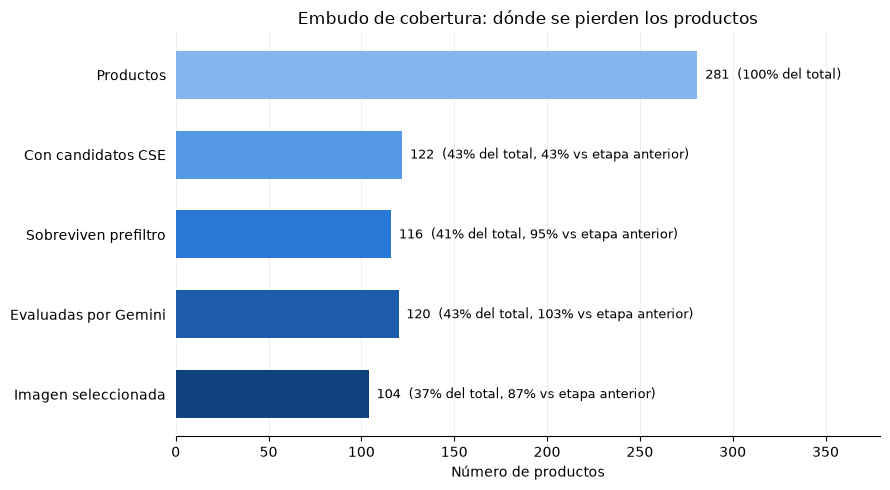

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paleta ordinal (un solo hue, mas oscuro = etapa mas avanzada del embudo)
FUNNEL_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]

stages = [
    ("Productos", int(resumen["productos"])),
    ("Con candidatos CSE", int((por_ref["n_cse"] > 0).sum())),
    ("Sobreviven prefiltro", int((por_ref["n_prefiltro"] > 0).sum())),
    ("Evaluadas por Gemini", int((por_ref["n_evaluadas"] > 0).sum())),
    ("Imagen seleccionada", int(resumen["con_imagen"])),
]
labels = [s[0] for s in stages]
values = [s[1] for s in stages]
total = values[0]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(labels))[::-1]  # primera etapa arriba

ax.barh(y, values, color=FUNNEL_COLORS, height=0.6)

prev_values = [None] + values[:-1]
for yi, v, prev in zip(y, values, prev_values):
    pct_total = f"{100 * v / total:.0f}% del total" if total else "-"
    retencion = f", {100 * v / prev:.0f}% vs etapa anterior" if prev else ""
    ax.text(v + total * 0.015, yi, f"{v}  ({pct_total}{retencion})", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, total * 1.35 if total else 1)
ax.set_xlabel("Número de productos")
ax.set_title("Embudo de cobertura: dónde se pierden los productos")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

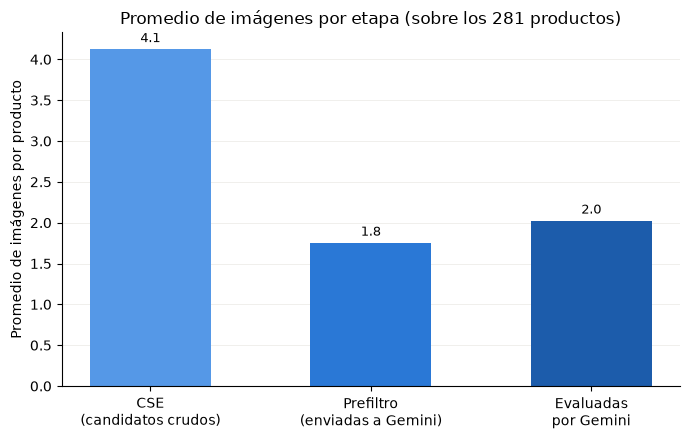

Promedio candidatos CSE (todos los productos):        4.1
Promedio candidatos CSE (solo con pool no vacío):      9.5
Promedio sobrevivientes prefiltro (mismo grupo):       4.0  -> retiene 43% del pool CSE
Promedio evaluadas por Gemini (solo con prefiltro no vacío): 4.8  -> retiene 112% del pool prefiltro


In [ ]:
# Promedio de candidatos que llegan a cada etapa, sobre TODOS los productos
# (incluyendo los que se quedan en 0 -> refleja la carga real del pipeline,
# no solo la de los que "tuvieron suerte")
avg_stage = {
    "CSE\n(candidatos crudos)": por_ref["n_cse"].mean(),
    "Prefiltro\n(enviadas a Gemini)": por_ref["n_prefiltro"].mean(),
    "Evaluadas\npor Gemini": por_ref["n_evaluadas"].mean(),
}

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(avg_stage.keys(), avg_stage.values(),
            color=["#5598e7", "#2a78d6", "#1c5cab"], width=0.55)

for bar, v in zip(bars, avg_stage.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.1f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Promedio de imágenes por producto")
ax.set_title(f"Promedio de imágenes por etapa (sobre los {len(por_ref)} productos)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Retención condicional: de los productos que SÍ llegaron vivos a una etapa,
# qué tanto sobrevive a la siguiente -> aísla el efecto de cada filtro del
# efecto de "no tenía nada que evaluar en primer lugar"
con_cse = por_ref[por_ref["n_cse"] > 0]
con_prefiltro = por_ref[por_ref["n_prefiltro"] > 0]

print(f"Promedio candidatos CSE (todos los productos):        {por_ref['n_cse'].mean():.1f}")
print(f"Promedio candidatos CSE (solo con pool no vacío):      {con_cse['n_cse'].mean():.1f}")
print(f"Promedio sobrevivientes prefiltro (mismo grupo):       {con_cse['n_prefiltro'].mean():.1f}"
    f"  -> retiene {100 * con_cse['n_prefiltro'].mean() / con_cse['n_cse'].mean():.0f}% del pool CSE")
print(f"Promedio evaluadas por Gemini (solo con prefiltro no vacío): {con_prefiltro['n_evaluadas'].mean():.1f}"
    f"  -> retiene {100 * con_prefiltro['n_evaluadas'].mean() / con_prefiltro['n_prefiltro'].mean():.0f}% del pool prefiltro")

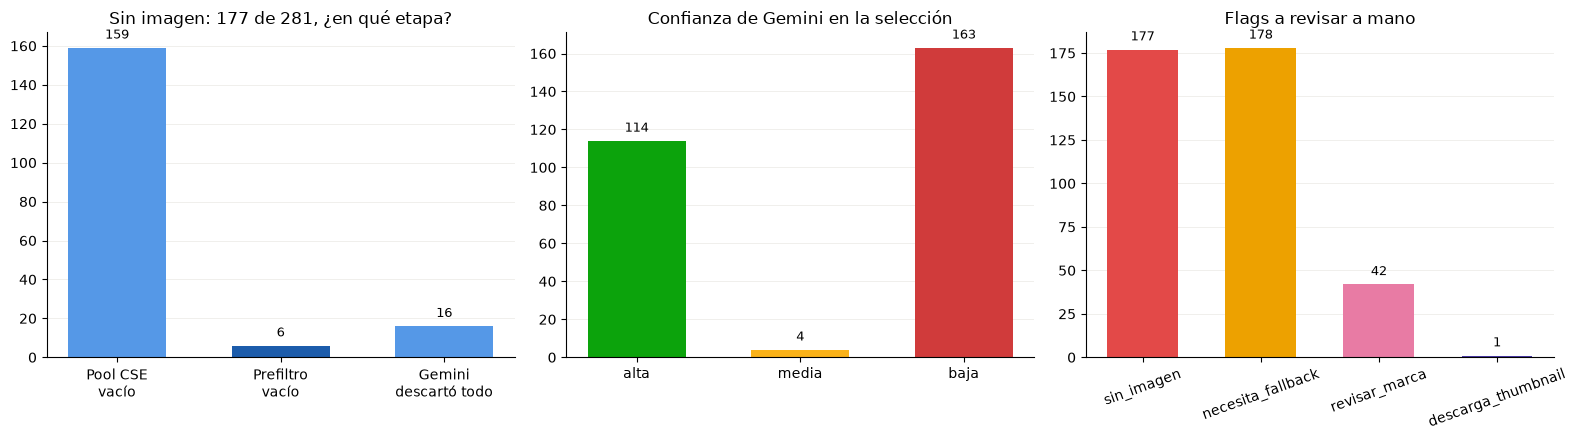

In [ ]:
# Por que se pierden los productos sin imagen (en que etapa se quedaron sin
# nada), que tan confiada estuvo la seleccion de Gemini, y que tan seguido
# aparece cada flag a revisar a mano.
razones_perdida = {
    "Pool CSE\nvacío": resumen["perdidos_pool_cse_vacio"],
    "Prefiltro\nvacío": resumen["perdidos_prefiltro_vacio"],
    "Gemini\ndescartó todo": resumen["perdidos_gemini_descarto"],
}

conf_order = ["alta", "media", "baja"]
conf_colors = ["#0ca30c", "#fab219", "#d03b3b"]  # paleta de estado: buena/alerta/critica
conf_counts = por_ref["confianza"].value_counts()
conf_vals = [int(conf_counts.get(c, 0)) for c in conf_order]

flag_order = ["sin_imagen", "necesita_fallback", "revisar_marca", "descarga_thumbnail"]
flag_colors = ["#e34948", "#eda100", "#e87ba4", "#4a3aa7"]  # slots categoricos fijos
flag_vals = [resumen["flags"].get(f, 0) for f in flag_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

def _bar_panel(ax, x_labels, values, colors, title):
    bars = ax.bar(x_labels, values, color=colors, width=0.6)
    ymax = max(values) if values and max(values) else 1
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + ymax * 0.02, str(v),
                ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

_bar_panel(axes[0], list(razones_perdida.keys()), list(razones_perdida.values()), FUNNEL_COLORS[1::2],
        f"Sin imagen: {resumen['sin_imagen']} de {resumen['productos']}, ¿en qué etapa?")
_bar_panel(axes[1], conf_order, conf_vals, conf_colors, "Confianza de Gemini en la selección")
_bar_panel(axes[2], flag_order, flag_vals, flag_colors, "Flags a revisar a mano")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()